In [5]:
import torch
import torch.nn as nn
import tiktoken

In [4]:
%pip install tiktoken

   ---------------------------------------- 0.0/944.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/944.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/944.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/944.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/944.1 kB ? eta -:--:--
   --------------------- ---------------- 524.3/944.1 kB 508.0 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/944.1 kB 508.0 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/944.1 kB 508.0 kB/s eta 0:00:01
   ------------------------------- ------ 786.4/944.1 kB 441.3 kB/s eta 0:00:01
   ------------------------------- ------ 786.4/944.1 kB 441.3 kB/s eta 0:00:01
   ---------------------------------------- 944.1/944.1 kB 419.7 kB/s  0:00:02

   -------------------- ------------------- 1/2 [tiktoken]
   ---------------------------------------- 2/2 [tiktoken]

Note: you may need to restart the kernel

In [6]:
import torch
import torch.nn as nn
import tiktoken

print("PyTorch:", torch.__version__)
print("tiktoken:", tiktoken.__version__)
print("All imports successful!")

PyTorch: 2.2.0+cu121
tiktoken: 0.14.0
All imports successful!


In [7]:
encoding = tiktoken.get_encoding("cl100k_base")

print("Encoding:", encoding.name)
print("Vocabulary size:", encoding.n_vocab)

Encoding: cl100k_base
Vocabulary size: 100277


In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tiktoken
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)

PyTorch version: 2.2.0+cu121
NumPy version: 2.2.6


In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [10]:
file_path = "IMDB Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (50000, 2)

Columns:
['review', 'sentiment']

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
print("Missing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

df, _ = train_test_split(
    df,
    train_size=3000,
    random_state=42,
    stratify=df["sentiment"]
)

df = df.reset_index(drop=True)

print("Subset shape:", df.shape)

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Subset shape: (3000, 2)

Sentiment distribution:
sentiment
positive    1500
negative    1500
Name: count, dtype: int64


In [14]:
df["sentiment"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df["sentiment"].value_counts())

print("\nFirst 5 labels:")
print(df["sentiment"].head())

sentiment
1    1500
0    1500
Name: count, dtype: int64

First 5 labels:
0    1
1    0
2    1
3    0
4    0
Name: sentiment, dtype: int64


In [15]:
texts = df["review"].values
labels = df["sentiment"].values

print("Number of reviews:", len(texts))
print("Number of labels:", len(labels))

Number of reviews: 3000
Number of labels: 3000


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2400
Testing samples: 600


In [17]:
encoding = tiktoken.get_encoding("cl100k_base")

print("Encoding:", encoding.name)
print("Vocabulary size:", encoding.n_vocab)

Encoding: cl100k_base
Vocabulary size: 100277


In [18]:
sample_text = X_train[0]

sample_tokens = encoding.encode(sample_text)

print("Original review:")
print(sample_text[:500])

print("\nFirst 30 token IDs:")
print(sample_tokens[:30])

print("\nNumber of tokens:")
print(len(sample_tokens))

Original review:
<br /><br />Oh my word!! I have never seen a film so lacking in any kind of moral judgement or consideration for anything other than the death of the scum! Michael Winner here makes a valid observation of human desires in displaying a gung-ho troth world of deep and damaged execution. Not only does he spoon feed us with utter hell on earth seen through the face of the moustached Bronson, but he also shows us the spoon he's feeding us with and says "look at what your watching now look at your sel

First 30 token IDs:
[9668, 24930, 1347, 6338, 12174, 856, 3492, 3001, 358, 617, 2646, 3970, 264, 4632, 779, 32161, 304, 904, 3169, 315, 16033, 48919, 477, 18361, 369, 4205, 1023, 1109, 279, 4648]

Number of tokens:
148


In [19]:
MAX_LENGTH = 200

print("Maximum sequence length:", MAX_LENGTH)

Maximum sequence length: 200


In [20]:
PAD_TOKEN = 0

def encode_and_pad(text, max_length=MAX_LENGTH):
    tokens = encoding.encode(text)

    # Truncate
    tokens = tokens[:max_length]

    # Shift every real token ID by +1
    # so that 0 can safely be used as padding
    tokens = [token + 1 for token in tokens]

    # Pad
    if len(tokens) < max_length:
        tokens = tokens + [PAD_TOKEN] * (
            max_length - len(tokens)
        )

    return tokens

In [21]:
test_sequence = encode_and_pad(
    "This movie was absolutely fantastic!"
)

print("Sequence:")
print(test_sequence[:30])

print("\nSequence length:")
print(len(test_sequence))

Sequence:
[2029, 5819, 575, 11113, 14965, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Sequence length:
200


In [22]:
X_train_encoded = [
    encode_and_pad(text)
    for text in X_train
]

X_test_encoded = [
    encode_and_pad(text)
    for text in X_test
]

print("Training sequences:", len(X_train_encoded))
print("Testing sequences:", len(X_test_encoded))

print("Sequence length:", len(X_train_encoded[0]))

Training sequences: 2400
Testing sequences: 600
Sequence length: 200


In [23]:
X_train_tensor = torch.tensor(
    X_train_encoded,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_encoded,
    dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("X_train tensor shape:", X_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([2400, 200])
X_test tensor shape: torch.Size([600, 200])
y_train tensor shape: torch.Size([2400])
y_test tensor shape: torch.Size([600])


In [24]:
BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 75
Testing batches: 19


In [25]:
class SimpleRNNClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=64,
        num_classes=2
    ):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=PAD_TOKEN
        )

        # Simple RNN
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Linear output layer
        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x):

        # x:
        # [batch_size, sequence_length]

        embedded = self.embedding(x)

        # embedded:
        # [batch_size, sequence_length, embedding_dim]

        output, hidden = self.rnn(embedded)

        # Take the final timestep
        last_output = output[:, -1, :]

        # Classification
        logits = self.fc(last_output)

        return logits

In [26]:
VOCAB_SIZE = encoding.n_vocab + 1

model = SimpleRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=128,
    hidden_dim=64,
    num_classes=2
)

model = model.to(device)

print(model)

SimpleRNNClassifier(
  (embedding): Embedding(100278, 128, padding_idx=0)
  (rnn): RNN(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [28]:
EPOCHS = 5

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_X)

        # Calculate loss
        loss = criterion(
            outputs,
            batch_y
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

        # Predictions
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"| Loss: {epoch_loss:.4f} "
        f"| Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5 | Loss: 0.7128 | Accuracy: 0.4721
Epoch 2/5 | Loss: 0.6780 | Accuracy: 0.5592
Epoch 3/5 | Loss: 0.6473 | Accuracy: 0.5908
Epoch 4/5 | Loss: 0.6212 | Accuracy: 0.6312
Epoch 5/5 | Loss: 0.5659 | Accuracy: 0.6687


In [30]:
# Cell 22 — Evaluate the RNN on the test set

model.eval()

all_predictions = []
all_actual = []

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        # Move input to device
        batch_X = batch_X.to(device)

        # Forward pass
        outputs = model(batch_X)

        # Get predicted class
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Convert tensors directly to Python lists
        all_predictions.extend(
            predictions.cpu().tolist()
        )

        all_actual.extend(
            batch_y.tolist()
        )

# Calculate accuracy without NumPy
correct = sum(
    pred == actual
    for pred, actual in zip(
        all_predictions,
        all_actual
    )
)

test_accuracy = correct / len(all_actual)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.5267
Test Accuracy: 52.67%


In [31]:
# Cell 23 — Classification Report

print(
    classification_report(
        all_actual,
        all_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.54      0.35      0.43       300
    Positive       0.52      0.70      0.60       300

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.51       600
weighted avg       0.53      0.53      0.51       600



In [32]:
# Cell 24 — Confusion Matrix

cm = confusion_matrix(
    all_actual,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[106 194]
 [ 90 210]]


In [33]:
# Cell 24 — Confusion Matrix without NumPy

true_negative = 0
false_positive = 0
false_negative = 0
true_positive = 0

for actual, predicted in zip(
    all_actual,
    all_predictions
):

    if actual == 0 and predicted == 0:
        true_negative += 1

    elif actual == 0 and predicted == 1:
        false_positive += 1

    elif actual == 1 and predicted == 0:
        false_negative += 1

    elif actual == 1 and predicted == 1:
        true_positive += 1

print("Confusion Matrix")
print("-----------------")
print(f"True Negative : {true_negative}")
print(f"False Positive: {false_positive}")
print(f"False Negative: {false_negative}")
print(f"True Positive : {true_positive}")

Confusion Matrix
-----------------
True Negative : 106
False Positive: 194
False Negative: 90
True Positive : 210


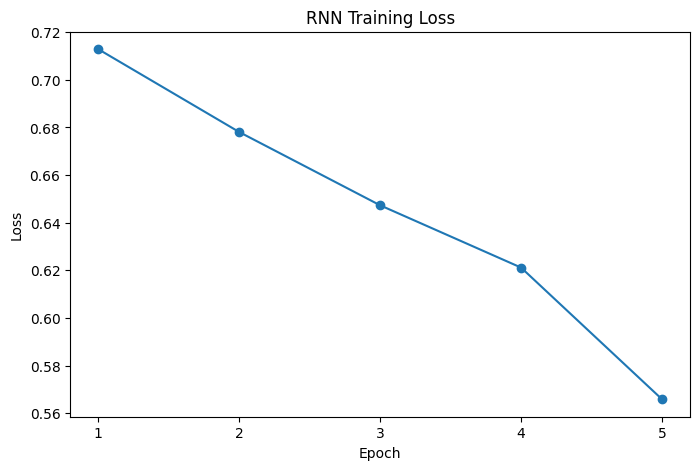

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Loss")

plt.xticks(
    range(1, EPOCHS + 1)
)

plt.show()

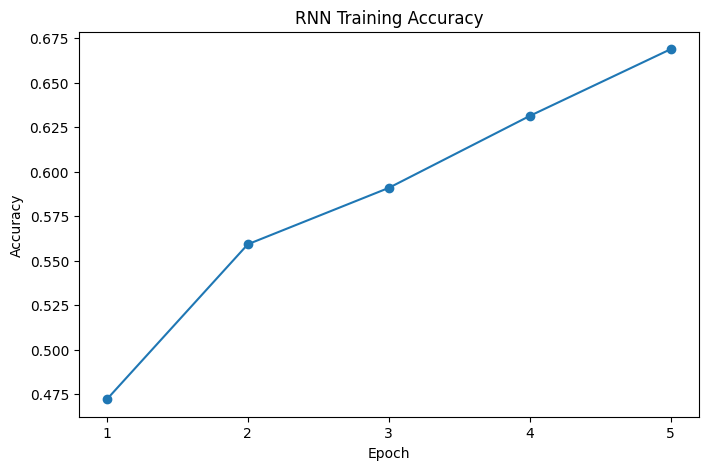

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training Accuracy")

plt.xticks(
    range(1, EPOCHS + 1)
)

plt.show()

In [36]:
def predict_review(review):

    model.eval()

    sequence = encode_and_pad(review)

    tensor = torch.tensor(
        [sequence],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        output = model(tensor)

        predicted_class = torch.argmax(
            output,
            dim=1
        ).item()

    if predicted_class == 1:
        return "Positive"
    else:
        return "Negative"

In [37]:
review = """
This movie was fantastic. The acting was excellent,
the story was interesting, and I really enjoyed watching it.
"""

prediction = predict_review(review)

print("Review:")
print(review)

print("\nPrediction:", prediction)

Review:

This movie was fantastic. The acting was excellent,
the story was interesting, and I really enjoyed watching it.


Prediction: Positive


In [38]:
review = """
This movie was terrible and boring. The story was weak,
the acting was poor, and I did not enjoy it at all.
"""

prediction = predict_review(review)

print("Review:")
print(review)

print("\nPrediction:", prediction)

Review:

This movie was terrible and boring. The story was weak,
the acting was poor, and I did not enjoy it at all.


Prediction: Positive
